In [20]:
from google.colab import files
uploaded = files.upload()

Saving titanic[1].csv to titanic[1].csv


   PassengerId  Survived  Pclass  \
0          892         0       3   
1          893         1       3   
2          894         0       2   
3          895         0       3   
4          896         1       3   

                                           Name     Sex   Age  SibSp  Parch  \
0                              Kelly, Mr. James    male  34.5      0      0   
1              Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
2                     Myles, Mr. Thomas Francis    male  62.0      0      0   
3                              Wirz, Mr. Albert    male  27.0      0      0   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   

    Ticket     Fare Cabin Embarked  
0   330911   7.8292   NaN        Q  
1   363272   7.0000   NaN        S  
2   240276   9.6875   NaN        Q  
3   315154   8.6625   NaN        S  
4  3101298  12.2875   NaN        S  


/tmp/ipykernel_437/510248713.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(), inplace=True)
/tmp/ipykernel_437/510248713.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

Accuracy: 1.0

Confusion Matrix
[[50  0]
 [ 0 34]]

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



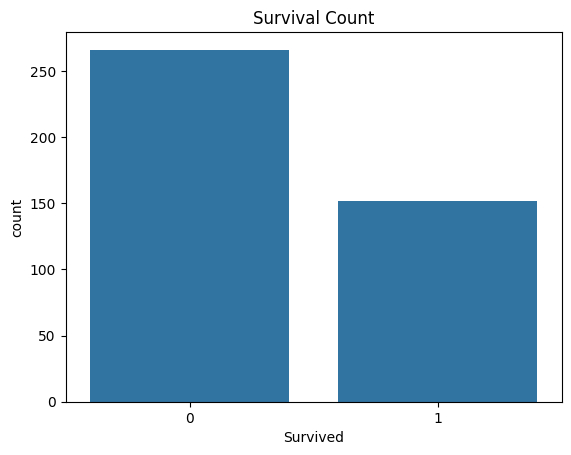

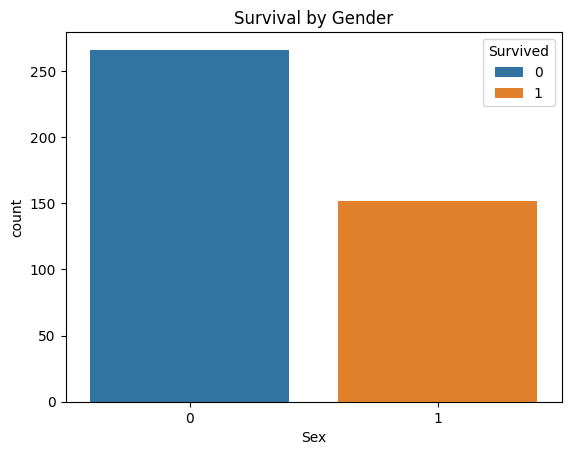

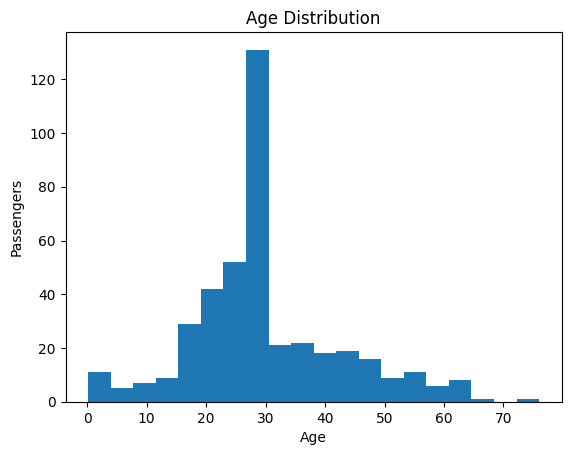

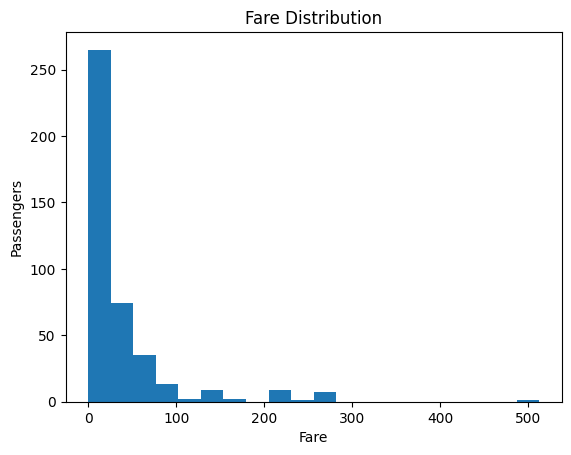

In [22]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv(list(uploaded.keys())[0])

# Show first rows
print(df.head())

# -------------------------
# Data Preprocessing
# -------------------------

# Fill Missing Values
df["Age"].fillna(df["Age"].mean(), inplace=True)
df["Fare"].fillna(df["Fare"].mean(), inplace=True)

# Drop unnecessary columns
df = df.drop(["PassengerId","Name","Ticket","Cabin"], axis=1)

# Convert categorical data
df["Sex"] = df["Sex"].map({"male":0,"female":1})
df["Embarked"] = df["Embarked"].map({"S":0,"C":1,"Q":2})

# Fill remaining missing values
df.fillna(0, inplace=True)

# -------------------------
# Define Features & Target
# -------------------------

X = df.drop("Survived", axis=1)
y = df["Survived"]

# Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------
# Train Model
# -------------------------

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

# -------------------------
# Prediction
# -------------------------

y_pred = model.predict(X_test)

# -------------------------
# Evaluation
# -------------------------

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

# -------------------------
# Diagrams / Visualization
# -------------------------

# Survival Count
sns.countplot(x="Survived", data=df)
plt.title("Survival Count")
plt.show()

# Survival by Gender
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Survival by Gender")
plt.show()

# Age Distribution
plt.hist(df["Age"], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Passengers")
plt.show()

# Fare Distribution
plt.hist(df["Fare"], bins=20)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Passengers")
plt.show()